In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


## Đọc và khám phá dữ liệu

In [2]:
df = pd.read_csv("house sale.csv")
df.head()

,Price,Address,City,Zipcode,State,Bedrooms,Bathrooms,Area (Sqft),Lot Size,Year Built
0,"$554,217","5926 Oak Ave, San Diego, CA 65383",San Diego,65383,CA,1 bds,3 ba,772 sqft,4757 sqft,1959
1,"$164,454","9583 Oak Ave, Fresno, IL 79339",Fresno,79339,IL,1 bds,1 ba,2348 sqft,3615 sqft,1969
2,"$1,249,331","8224 Oak Ave, Sacramento, TX 87393",Sacramento,87393,TX,6 bds,1 ba,3630 sqft,9369 sqft,1990
3,"$189,267","232 Oak Ave, Fresno, TX 38666",Fresno,38666,TX,2 bds,1 ba,605 sqft,8804 sqft,1958
4,"$465,778","5446 Pine Rd, Los Angeles, CA 23989",Los Angeles,23989,CA,3 bds,2 ba,1711 sqft,9260 sqft,2020


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Price        3000 non-null   str  
 1   Address      3000 non-null   str  
 2   City         3000 non-null   str  
 3   Zipcode      3000 non-null   int64
 4   State        3000 non-null   str  
 5   Bedrooms     3000 non-null   str  
 6   Bathrooms    3000 non-null   str  
 7   Area (Sqft)  3000 non-null   str  
 8   Lot Size     3000 non-null   str  
 9   Year Built   3000 non-null   int64
dtypes: int64(2), str(8)
memory usage: 234.5 KB


,Zipcode,Year Built
count,3000.000000,3000.000000
mean,55264.197333,1986.814333
std,25923.967932,21.272252
min,10006.000000,1950.000000
25%,33363.500000,1968.000000
50%,55467.500000,1987.000000
75%,77692.250000,2006.000000
max,99955.000000,2023.000000


## Tiền xử lý dữ liệu

Trong bộ dữ liệu có một số cột chứa ký tự như "$", dấu phẩy, "Beds", "Baths", "sqft"... Các ký tự này không thể sử dụng trực tiếp để huấn luyện mô hình.

Do đó cần loại bỏ các ký tự đặc biệt và chuyển dữ liệu sang kiểu số.

In [ ]:
df["Price"] = (
    df["Price"]
    .str.replace("$","",regex=False)
    .str.replace(",","",regex=False)
    .astype(float)
)

In [ ]:
df["Bedrooms"] = (
    df["Bedrooms"]
    .str.replace("bds","",regex=False)
    .astype(float)
)

In [11]:
df["Bathrooms"] = (
    df["Bathrooms"]
    .str.replace("ba","",regex=False)
    .astype(float)
)

In [13]:
df["Area (Sqft)"] = (
    df["Area (Sqft)"]
    .str.replace("sqft","",regex=False)
    .astype(float)
)

In [15]:
df["Lot Size"] = (
    df["Lot Size"]
    .str.replace("sqft","",regex=False)
    .astype(float)
)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Price        3000 non-null   float64
 1   Address      3000 non-null   str    
 2   City         3000 non-null   str    
 3   Zipcode      3000 non-null   int64  
 4   State        3000 non-null   str    
 5   Bedrooms     3000 non-null   float64
 6   Bathrooms    3000 non-null   float64
 7   Area (Sqft)  3000 non-null   float64
 8   Lot Size     3000 non-null   float64
 9   Year Built   3000 non-null   int64  
dtypes: float64(5), int64(2), str(3)
memory usage: 234.5 KB


In [17]:
df.head(10)

,Price,Address,City,Zipcode,State,Bedrooms,Bathrooms,Area (Sqft),Lot Size,Year Built
0,554217.0,"5926 Oak Ave, San Diego, CA 65383",San Diego,65383,CA,1.0,3.0,772.0,4757.0,1959
1,164454.0,"9583 Oak Ave, Fresno, IL 79339",Fresno,79339,IL,1.0,1.0,2348.0,3615.0,1969
2,1249331.0,"8224 Oak Ave, Sacramento, TX 87393",Sacramento,87393,TX,6.0,1.0,3630.0,9369.0,1990
3,189267.0,"232 Oak Ave, Fresno, TX 38666",Fresno,38666,TX,2.0,1.0,605.0,8804.0,1958
4,465778.0,"5446 Pine Rd, Los Angeles, CA 23989",Los Angeles,23989,CA,3.0,2.0,1711.0,9260.0,2020
5,738357.0,"9202 Maple Dr, Sacramento, NY 71318",Sacramento,71318,NY,5.0,3.0,1177.0,8317.0,2015
6,1325395.0,"2698 Elm St, Sacramento, NY 57421",Sacramento,57421,NY,6.0,1.0,1990.0,5592.0,2012
7,1158003.0,"2118 Main St, San Diego, IL 64361",San Diego,64361,IL,2.0,2.0,1008.0,6010.0,1975
8,240095.0,"9474 Main St, San Francisco, FL 13227",San Francisco,13227,FL,6.0,2.0,929.0,5449.0,1975
9,1356448.0,"8803 Maple Dr, San Diego, NY 57397",San Diego,57397,NY,2.0,3.0,2094.0,2179.0,1970


## Lựa chọn đặc trưng

Để dự đoán giá nhà, nhóm lựa chọn các thuộc tính có ảnh hưởng trực tiếp đến giá bán, gồm:

- Bedrooms
- Bathrooms
- Area (Sqft)
- Lot Size
- Year Built

Trong đó:

- Biến đầu vào (X): các đặc trưng trên.
- Biến đầu ra (y): Price.

In [18]:
X = df[
    [
        "Bedrooms",
        "Bathrooms",
        "Area (Sqft)",
        "Lot Size",
        "Year Built"
    ]
]

y = df["Price"]

## Trực quan hóa dữ liệu

Việc trực quan hóa giúp quan sát mối quan hệ giữa các thuộc tính trong bộ dữ liệu.

Ngoài ra, biểu đồ còn giúp phát hiện các giá trị bất thường và đánh giá mức độ tương quan giữa các biến.

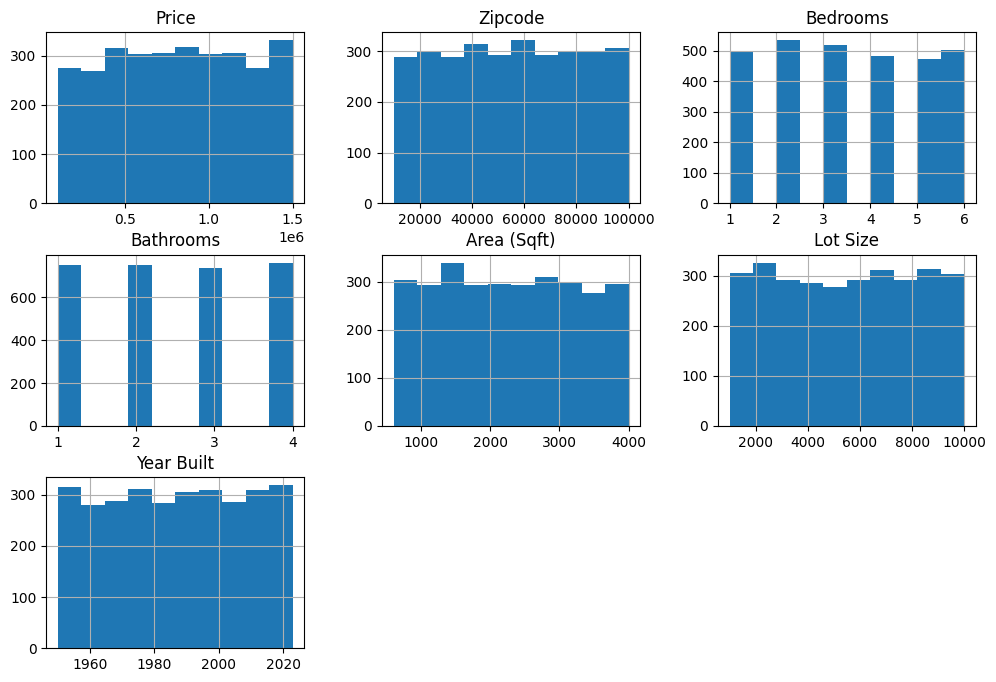

In [19]:
df.hist(figsize=(12,8))
plt.show()

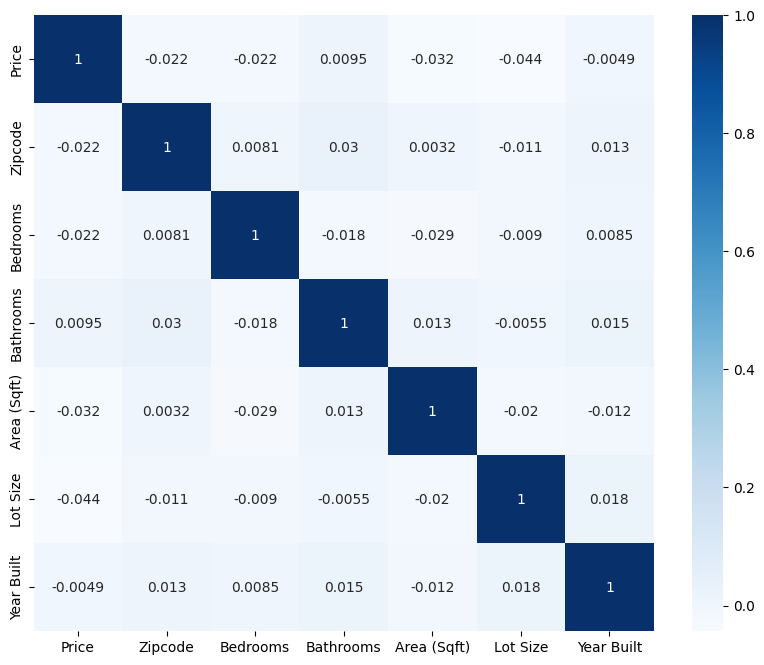

In [22]:
plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues")

plt.show()

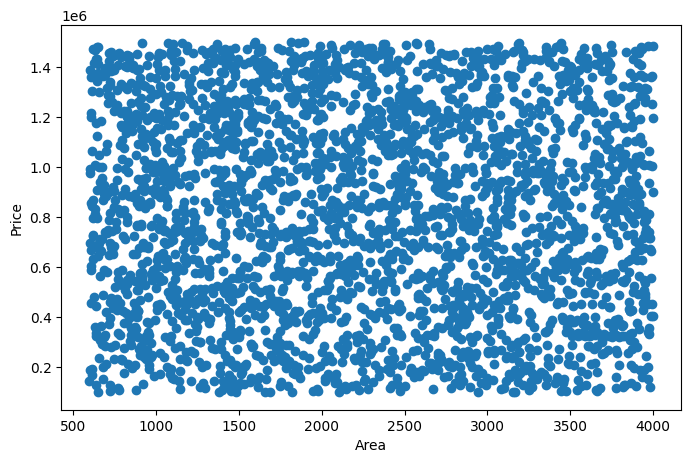

In [21]:
plt.figure(figsize=(8,5))

plt.scatter(df["Area (Sqft)"],df["Price"])

plt.xlabel("Area")

plt.ylabel("Price")

plt.show()

## Chia tập dữ liệu

Để đánh giá mô hình khách quan, bộ dữ liệu được chia thành hai phần:

- 80% dùng để huấn luyện mô hình.
- 20% dùng để kiểm tra mô hình.

Việc chia dữ liệu giúp đánh giá khả năng dự đoán của mô hình trên dữ liệu chưa từng được học.

In [23]:
X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

## Xây dựng mô hình Linear Regression

Linear Regression là thuật toán học có giám sát dùng để dự đoán giá trị liên tục.

Thuật toán sẽ tìm đường thẳng phù hợp nhất giữa các đặc trưng đầu vào và giá nhà sao cho sai số dự đoán là nhỏ nhất.

In [24]:
model=LinearRegression()

model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
print(model.intercept_)

print(model.coef_)

257308.34168299276
[-1470.50030754  4895.14132348   -19.02992399    -7.40417863
   319.04596886]


## Đánh giá mô hình

Sau khi huấn luyện, mô hình được đánh giá bằng các chỉ số:

- MAE (Mean Absolute Error): sai số tuyệt đối trung bình.
- RMSE (Root Mean Squared Error): căn bậc hai của sai số bình phương trung bình.
- R² Score: mức độ giải thích của mô hình đối với dữ liệu.

MAE và RMSE càng nhỏ thì mô hình càng tốt.

R² càng gần 1 thì mô hình càng chính xác.

In [26]:
y_pred=model.predict(X_test)

In [27]:
mae=mean_absolute_error(y_test,y_pred)

print(mae)

357090.43858841975


In [28]:
rmse=np.sqrt(mean_squared_error(y_test,y_pred))

print(rmse)

410804.4875347419


In [29]:
r2=r2_score(y_test,y_pred)

print(r2)

-0.008208296069803556


## 10. Dự đoán giá nhà mới

Sau khi mô hình được huấn luyện, tiến hành nhập thông tin của một căn nhà mới để dự đoán giá bán.

Kết quả dự đoán sẽ được sử dụng để kiểm tra khả năng hoạt động của mô hình.

In [31]:
new_house=[[6,2,2800,7000,2006]]

price=model.predict(new_house)

print(price)

[793168.79843435]


c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
